[1 0 0 2 0 4 0 4 1 1 3 2 0 3 2 4 2 4 0 2 1 4 2 2 1 3 1 1 3 2 1 0 0 3 0 1 1
 4 4 4 3 4 2 2 0 0 4 0 1 3 0 4 1 1 4 0 4 4 3 2 1 4 1 2 0 3 2 3 0 0 2 1 2 4
 0 2 1 1 2 1 2 3 0 0 4 1 4 0 0 2 2 3 3 2 4 1 1 2 3 0 1 3 3 1 3 2 4 1 1 0 0
 2 1 4 4 3 3 3 1 4 4 2 0 3 2 0 4 2 3 3 3 1 0 4 3 4 4 4 0 2 1 3 1 2 1 4 4 3
 1 0 0 3 3 1 2 0 0 0 3 2 3 4 2 0 1 1 2 1 4 1 2 0 4 4 1 3 2 3 0 3 0 3 3 4 2
 4 1 0 3 4 3 1 4 2 1 2 2 4 3 3 1 3 0 3 3 1 4 2 2 0 4 3 0 3 4 3 4 1 1 0 1 2
 4 4 4 0 2 4 4 2 1 2 0 3 3 2 3 2 4 0 1 0 3 4 1 1 3 3 1 4 4 0 1 1 0 0 2 0 2
 3 4 2 3 1 0 2 4 1 2 0 0 3 2 1 3 1 3 1 3 3 2 1 1 1 0 1 3 2 3 4 2 0 0 0 1 4
 3 2 4 3 4 0 1 1 3 0 4 1 1 3 4 3 0 4 0 2 0 4 4 4 3 3 0 1 0 3 4 4 1 1 3 2 1
 0 0 2 2 3 1 4 2 0 2 4 1 1 1 3 0 2 2 1 2 0 1 1 2 0 0 4 2 0 4 0 2 1 2 1 3 3
 1 2 4 0 1 1 4 0 3 0 4 4 0 4 4 3 3 4 2 3 3 3 2 4 4 4 4 1 3 1 0 2 4 1 1 0 2
 0 2 3 4 0 4 3 0 2 4 3 0 1 4 2 3 0 1 0 2 3 1 0 2 4 3 1 3 1 0 3 1 3 1 4 0 0
 3 1 1 0 0 2 0 2 4 2 2 1 4 2 3 2 4 3 0 4 2 2 3 2 2 0 4 2 3 1 0 2 3 4 0 4 2
 4 1 4 0 3 2 3 3 3 2 4 2 

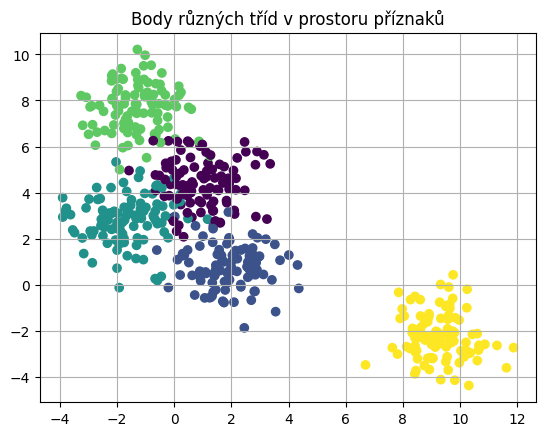

In [3]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
# generování bodů
X, y = make_blobs(n_samples=500, centers=5, n_features=2, random_state=0)
print(y)
plt.scatter(X[:,0],X[:,1], c = y)
plt.grid()
plt.title("Body různých tříd v prostoru příznaků")
plt.show()

In [4]:
import numpy as np
def L2(x,y):
  return np.sqrt((x-y) @ (x-y))

def L1(x,y):
  return np.sum(np.abs(x-y))

x=np.array([1,2,3])
y=np.array([0,1,4])

print(f"L2: {L2(x,y)}")
print(f"L1: {L1(x,y)}")

L2: 1.7320508075688772
L1: 3


(500, 2)
Posun v iteraci 0::18.04836370964432
Posun v iteraci 1::6.4951604951431285
Posun v iteraci 2::3.4199397353758547
Posun v iteraci 3::1.9722116221717938
Posun v iteraci 4::2.4127138406754014
Posun v iteraci 5::1.718164987456275
Posun v iteraci 6::0.9885437874215649
Posun v iteraci 7::0.26755915050433565
Posun v iteraci 8::0.27990233567665324
Posun v iteraci 9::0.19263137385153206
Posun v iteraci 10::0.045848911986485885
Posun v iteraci 11::0.0
HOTOVO 


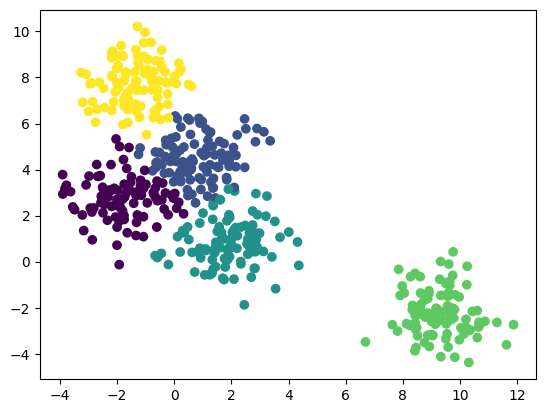

In [5]:
def shlukuj(X,k,vzdalenost=L2, TOL=1e-3, MAXITER=50):
  # inicializace
  dim = X.shape[1] # dimenze ulohy
  teziste = np.random.rand(k,dim) #minima+(maxima-minima)*np.random.rand(k,dim) # prenes si to do meritka
  teziste_nove=np.zeros((k,dim))#pomocne pole pro ulozeni tezist
  kampatri = [0 for i in range(X.shape[0])]
  # iteruj
  for iterace in range(MAXITER):
    # ------prirad body tezisti------------
    for index, bod in enumerate(X):
      nejblizsi = 0
      rnejblizsi = vzdalenost(bod, teziste[nejblizsi,:]) # spocti vzdalenost od prvniho teziste
      for i in range(1,k): #pocitej pro vsechny dalsi
        r = vzdalenost(bod,teziste[i,:])
        if rnejblizsi > r :
          rnejblizsi = r
          nejblizsi = i
      kampatri[index] = nejblizsi  # zapamatuj si nejblizsi teziste k danemu bodu
    # ------------ spocti nova teziste ------------------
    teziste_nove = np.zeros((k,dim))
    for i in range(k): # pro kazde teziste delej
      n = 0
      for index, bod in enumerate(X): # prochazej body
        if kampatri[index] == i: # kdyz to patri danemu tezisti
            teziste_nove[i,:]+=bod
            n+=1
      if n > 0:
        teziste_nove[i,:]=teziste_nove[i,:]/n

    # vypocet posunu:
    posun = np.array([vzdalenost(teziste[i], teziste_nove[i]) for i in range(k)]).sum()
    print(f"Posun v iteraci {iterace}::{posun}")
    if posun < TOL :
      break
    teziste=teziste_nove
  # konec iteraci
  print("HOTOVO ")
  return kampatri

#X[:,1] = X[:,1]*100
print(X.shape)
clustery=shlukuj(X,k=5, vzdalenost=L1)
plt.scatter(X[:,0],X[:,1], c = clustery)

# KMEANS vs obrazek

In [6]:
from sklearn.cluster import KMeans
from PIL import Image
import numpy as np
image = Image.open('P9010058.JPG')

In [7]:
data=np.array(image)/255
height=data.shape[0]
width=data.shape[1]
print(data.shape)
X=data.reshape(height*width,3)
print(X.shape)
print(X[0])

(3234, 4313, 3)
(13948242, 3)
[0.51764706 0.34901961 0.21176471]


In [8]:
index  = np.random.randint(X.shape[0], size=10000)

In [9]:
kmeans = KMeans(n_clusters=64, random_state=0, n_init="auto").fit(X[index])

In [10]:
cluster_ids=kmeans.predict(X)


In [11]:
centers = kmeans.cluster_centers_
XX=np.zeros(X.shape)
for i in range(XX.shape[0]):
  XX[i]=centers[cluster_ids[i]]

print(XX[:10])
print(X[:10])

[[0.52364561 0.36842411 0.23215686]
 [0.52364561 0.36842411 0.23215686]
 [0.52364561 0.36842411 0.23215686]
 [0.52364561 0.36842411 0.23215686]
 [0.52364561 0.36842411 0.23215686]
 [0.52364561 0.36842411 0.23215686]
 [0.52364561 0.36842411 0.23215686]
 [0.52364561 0.36842411 0.23215686]
 [0.52364561 0.36842411 0.23215686]
 [0.52364561 0.36842411 0.23215686]]
[[0.51764706 0.34901961 0.21176471]
 [0.51372549 0.34509804 0.20784314]
 [0.51372549 0.34509804 0.20784314]
 [0.51372549 0.34509804 0.20784314]
 [0.51764706 0.34901961 0.21176471]
 [0.51764706 0.34901961 0.21176471]
 [0.51372549 0.35686275 0.21568627]
 [0.51764706 0.36078431 0.21960784]
 [0.52156863 0.36470588 0.22352941]
 [0.52156863 0.36470588 0.22352941]]


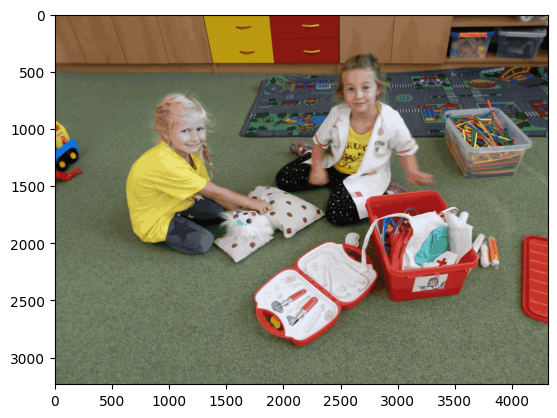

In [12]:
import matplotlib.pyplot as plt
plt.imshow(XX.reshape(height,width,3))


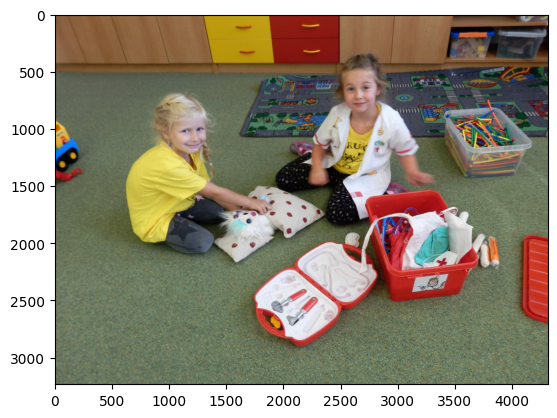

In [13]:
plt.imshow(X.reshape(height,width,3))